# Imports

In [60]:
import pandas as pd
# import ast
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 500)

# Reading in the raw data

In [61]:
df_raw = pd.read_csv("../data/raw/ChestX-ray14/Data_Entry_2017.csv")
df_raw = df_raw.drop(columns="Unnamed: 11")

In [62]:
df_raw.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143


In [63]:
print(df_raw["Patient Age"].describe())
print(df_raw[df_raw["Patient Age"] == 0].shape[0])
print(df_raw[df_raw["Patient Age"] > 100].shape[0])
df_raw[df_raw["Patient Age"] > 100]

count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64
0
16


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
20852,00005567_000.png,Effusion|Pneumonia,0,5567,412,M,AP,3056,2544,0.139,0.139
46965,00011973_002.png,Edema,2,11973,414,M,AP,3056,2544,0.139,0.139
48284,00012238_010.png,No Finding,10,12238,148,M,PA,2992,2991,0.143,0.143
55742,00013950_000.png,No Finding,0,13950,148,M,PA,2964,2939,0.143,0.143
58650,00014520_026.png,Infiltration|Mass,26,14520,150,M,PA,2992,2991,0.143,0.143
62929,00015558_000.png,No Finding,0,15558,149,M,PA,2992,2991,0.143,0.143
74884,00018366_044.png,Pneumothorax,44,18366,152,F,PA,2302,2991,0.143,0.143
78795,00019346_000.png,Infiltration,0,19346,151,F,PA,2678,2774,0.143,0.143
84810,00020900_002.png,No Finding,2,20900,411,M,AP,3056,2544,0.139,0.139
85404,00021047_002.png,Mass|Pleural_Thickening,2,21047,412,M,AP,3056,2544,0.139,0.139


In [64]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
dtypes: float64(2), int64(5), object(4)
memory usage: 9.4+ MB


In [65]:
df_raw["Patient ID"].nunique()

30805

In [66]:
df_raw.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
count,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000
mean,8.573751,14346.381743,46.901463,2646.078844,2486.438842,0.155649,0.155649
std,15.406320,8403.876972,16.839923,341.246429,401.268227,0.016174,0.016174
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000
25%,0.000000,7310.750000,35.000000,2500.000000,2048.000000,0.143000,0.143000
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000
max,183.000000,30805.000000,414.000000,3827.000000,4715.000000,0.198800,0.198800


In [67]:
view_counts = df_raw["Finding Labels"].value_counts()
view_counts[:20]

Finding Labels
No Finding                           60361
Infiltration                          9547
Atelectasis                           4215
Effusion                              3955
Nodule                                2705
Pneumothorax                          2194
Mass                                  2139
Effusion|Infiltration                 1603
Atelectasis|Infiltration              1350
Consolidation                         1310
Atelectasis|Effusion                  1165
Pleural_Thickening                    1126
Cardiomegaly                          1093
Emphysema                              892
Infiltration|Nodule                    829
Atelectasis|Effusion|Infiltration      737
Fibrosis                               727
Edema                                  628
Cardiomegaly|Effusion                  484
Consolidation|Infiltration             441
Name: count, dtype: int64

# Plotting the data

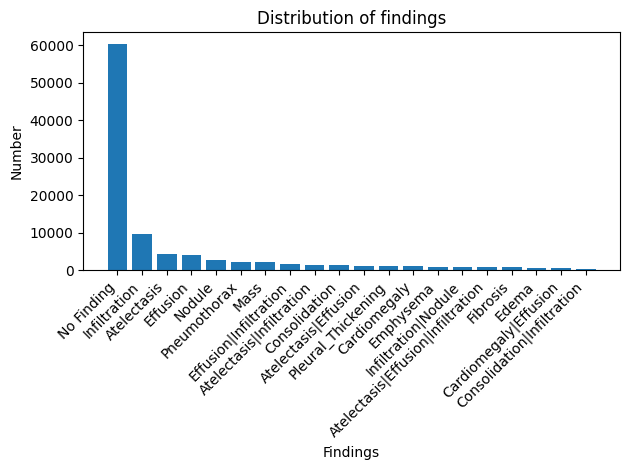

In [68]:
plt.figure()
view_counts = df_raw["Finding Labels"].value_counts()
plt.bar(view_counts[:20].index, view_counts[:20].values)
plt.title("Distribution of findings")
plt.xlabel("Findings")
plt.ylabel("Number")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [69]:
label_sex_crosstab = (df_raw.explode("Finding Labels").pivot_table(index="Finding Labels", columns="Patient Gender", 
                                   aggfunc="size", fill_value=0).sort_values(by=["F", "M"], ascending=False))
label_sex_crosstab[:5]

Patient Gender,F,M
Finding Labels,,
No Finding,26439,33922
Infiltration,4164,5383
Effusion,1797,2158
Atelectasis,1612,2603
Pneumothorax,1193,1001


<Figure size 640x480 with 0 Axes>

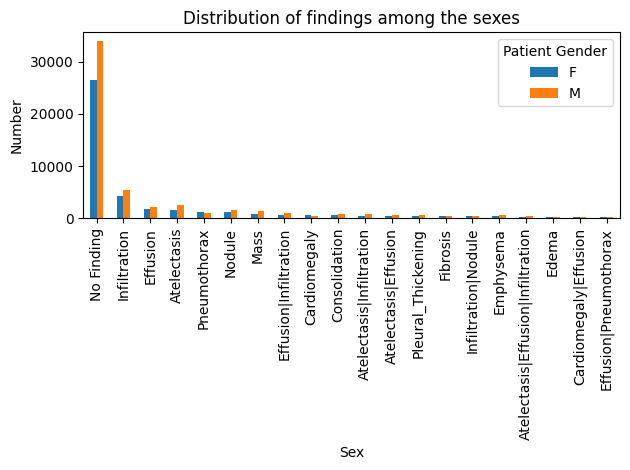

In [70]:
plt.figure()

label_sex_crosstab[:20].plot(kind="bar")
plt.title("Distribution of findings among the sexes")
plt.xlabel("Sex")
plt.ylabel("Number")
plt.tight_layout()
plt.show()

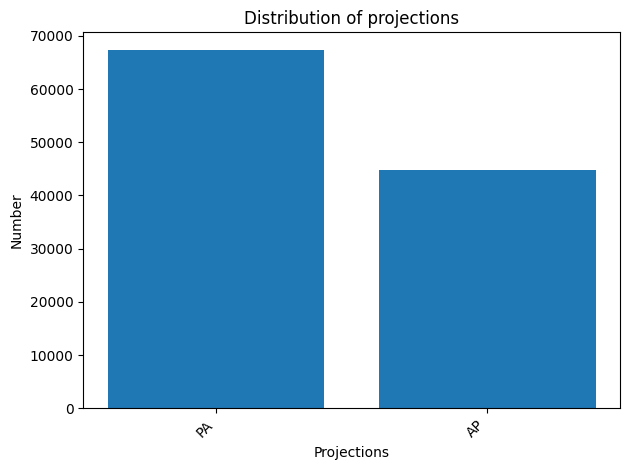

In [71]:
plt.figure()
view_counts = df_raw["View Position"].value_counts()
plt.bar(view_counts[:10].index, view_counts[:10].values)
plt.title("Distribution of projections")
plt.xlabel("Projections")
plt.ylabel("Number")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Reading in the processed data, and the drain data

In [72]:
# df_drains_pos = pd.read_csv("../data/raw/ChestX-ray14/NIH-CX14_TubeAnnotations_NonExperts_aggregated.csv", index_col=0)
df_train = pd.read_csv("../data/processed/ChestX-ray14/train/files/processed_labels_train.csv", index_col=0)
df_test = pd.read_csv("../data/processed/ChestX-ray14/test/files/processed_labels_drains.csv", index_col=0)

In [73]:
print("df_train", df_train["View Position"].value_counts())
print("df_test", df_test["View Position"].value_counts())

df_train View Position
PA    56214
AP    30310
Name: count, dtype: int64
df_test View Position
AP    14500
PA    11096
Name: count, dtype: int64


In [74]:
print(df_train["Image Index"].nunique())
print(df_test["Image Index"].nunique())

86524
25596


In [75]:
df_train.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Pneumothorax
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,False
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,False
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,False
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,False
12,00000004_000.png,Mass|Nodule,0,4,82,M,AP,2500,2048,0.168,0.168,NaN,False


In [76]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86524 entries, 0 to 112115
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Image Index                  86524 non-null  object 
 1   Finding Labels               86524 non-null  object 
 2   Follow-up #                  86524 non-null  int64  
 3   Patient ID                   86524 non-null  int64  
 4   Patient Age                  86524 non-null  int64  
 5   Patient Gender               86524 non-null  object 
 6   View Position                86524 non-null  object 
 7   OriginalImage[Width          86524 non-null  int64  
 8   Height]                      86524 non-null  int64  
 9   OriginalImagePixelSpacing[x  86524 non-null  float64
 10  y]                           86524 non-null  float64
 11  Unnamed: 11                  0 non-null      float64
 12  Pneumothorax                 86524 non-null  bool   
dtypes: bool(1), float64(

# Investigating `df_train`

### We will use `df_train` as that is the one that contains all the necessary data

In [77]:
df_train = df_train.drop(columns="Unnamed: 11")
df_train.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Pneumothorax
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,False
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,False
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,False
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,False
12,00000004_000.png,Mass|Nodule,0,4,82,M,AP,2500,2048,0.168,0.168,False


## Sanity checking the dataset

In [78]:
print(df_train["Image Index"].nunique())
print(df_train["Patient ID"].nunique())

86524
28008


In [79]:
df_train.sort_values(by="Follow-up #", ascending=False)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Pneumothorax
82758,00020326_108.png,No Finding,108,20326,27,F,AP,3056,2544,0.139,0.139,False
82757,00020326_107.png,No Finding,107,20326,27,F,AP,2500,2048,0.168,0.168,False
78197,00019176_107.png,Effusion|Infiltration,107,19176,67,F,AP,3056,2544,0.139,0.139,False
78196,00019176_106.png,Infiltration,106,19176,67,F,AP,3056,2544,0.139,0.139,False
82756,00020326_106.png,Infiltration,106,20326,27,F,AP,2500,2048,0.168,0.168,False
...,...,...,...,...,...,...,...,...,...,...,...,...
55109,00013802_000.png,Infiltration,0,13802,57,M,PA,2992,2991,0.143,0.143,False
55110,00013803_000.png,No Finding,0,13803,77,M,PA,2992,2991,0.143,0.143,False
55111,00013804_000.png,Infiltration,0,13804,34,M,PA,2992,2991,0.143,0.143,False
55112,00013805_000.png,Infiltration,0,13805,55,M,PA,2992,2991,0.143,0.143,False


In [80]:
df_train[(df_train["Patient ID"] == 20326) & (df_train["Pneumothorax"] == False)]
df_train[(df_train["Patient ID"] == 20326) & (df_train["Pneumothorax"] == True)]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Pneumothorax
82713,00020326_063.png,Pneumothorax,63,20326,27,F,AP,2500,2048,0.168,0.168,True


In [81]:
print(df_train["Patient Age"].describe())
print(df_train[df_train["Patient Age"] == 0].shape[0])
print(df_train[df_train["Patient Age"] > 100].shape[0])

count    86524.000000
mean        46.870071
std         16.835434
min          1.000000
25%         35.000000
50%         49.000000
75%         59.000000
max        413.000000
Name: Patient Age, dtype: float64
0
12


In [82]:
df_raw.sort_values(by="Patient Age", ascending=False).head(20)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
46965,00011973_002.png,Edema,2,11973,414,M,AP,3056,2544,0.139,0.139
86264,00021275_003.png,No Finding,3,21275,413,F,AP,3056,2544,0.139,0.139
91369,00022811_000.png,No Finding,0,22811,412,M,PA,3056,2544,0.139,0.139
85404,00021047_002.png,Mass|Pleural_Thickening,2,21047,412,M,AP,3056,2544,0.139,0.139
20852,00005567_000.png,Effusion|Pneumonia,0,5567,412,M,AP,3056,2544,0.139,0.139
84810,00020900_002.png,No Finding,2,20900,411,M,AP,3056,2544,0.139,0.139
101194,00026871_000.png,No Finding,0,26871,155,F,PA,2992,2991,0.143,0.143
104590,00027989_000.png,No Finding,0,27989,155,M,PA,2992,2991,0.143,0.143
98495,00026028_001.png,Atelectasis,1,26028,154,M,PA,2992,2991,0.143,0.143
95794,00025206_000.png,Infiltration|Mass,0,25206,153,M,PA,2992,2991,0.143,0.143


In [83]:
df_raw[df_raw["Patient Age"] > 100].shape

(16, 11)

In [84]:
df_train[df_train["Patient Age"] > 100].shape

(12, 12)

# Investigating `df_test`

### We will use `df_test` as that is the one that contains all the necessary data
Such as the drain annotations for the positive AND negative cases of pneumothorax

In [85]:
df_test = df_test.drop(columns=["Unnamed: 11", "Unnamed: 0"])
df_test.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
0,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,143.0,143.0,NaN,NaN,NaN,NaN,0.0,False
1,00000003_001.png,Hernia,1,3,74,F,PA,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
2,00000003_002.png,Hernia,2,3,75,F,PA,2048,2500,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
3,00000003_003.png,Hernia|Infiltration,3,3,76,F,PA,2698,2991,143.0,143.0,NaN,NaN,NaN,NaN,0.0,False
4,00000003_004.png,Hernia,4,3,77,F,PA,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False


## Sanity checking the dataset

In [86]:
print(df_test["Image Index"].nunique())
print(df_test["Patient ID"].nunique())

25596
2797


In [87]:
df_test.sort_values(by="Follow-up #", ascending=False)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
6428,00010007_183.png,Effusion|Infiltration,183,10007,59,M,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,0.0,False
6427,00010007_182.png,Consolidation,182,10007,59,M,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,1.0,False
6426,00010007_181.png,No Finding,181,10007,59,M,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,0.0,False
6425,00010007_180.png,Infiltration|Pleural_Thickening,180,10007,59,M,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,0.0,False
6424,00010007_179.png,Atelectasis|Effusion,179,10007,59,M,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22180,00028309_000.png,No Finding,0,28309,21,M,PA,2544,3056,139.000000,139.000000,NaN,NaN,NaN,NaN,0.0,False
22181,00028310_000.png,No Finding,0,28310,62,M,PA,2992,2991,143.000000,143.000000,NaN,NaN,NaN,NaN,1.0,False
22182,00028311_000.png,No Finding,0,28311,32,F,PA,2544,3056,139.000000,139.000000,NaN,NaN,NaN,NaN,1.0,False
22183,00028312_000.png,No Finding,0,28312,59,F,PA,1843,1826,0.194311,0.194311,NaN,NaN,NaN,NaN,0.0,False


In [88]:
df_test[(df_test["Patient ID"] == 10007) & (df_test["Pneumothorax"] == False)]
df_test[(df_test["Patient ID"] == 10007) & (df_test["Pneumothorax"] == True)]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
6293,00010007_048.png,Infiltration|Pleural_Thickening|Pneumothorax,48,10007,58,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,True
6299,00010007_054.png,Effusion|Infiltration|Pneumothorax,54,10007,58,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,True
6300,00010007_055.png,Effusion|Infiltration|Pneumothorax,55,10007,58,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,1.0,True
6301,00010007_056.png,Effusion|Infiltration|Pneumothorax,56,10007,58,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,1.0,True
6423,00010007_178.png,Effusion|Pneumothorax,178,10007,59,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,True


In [89]:
print(df_test["Patient Age"].describe())
print(df_test[df_test["Patient Age"] == 0].shape[0])
print(df_test[df_test["Patient Age"] > 100].shape[0])

count    25596.000000
mean        47.007579
std         16.854982
min          1.000000
25%         34.000000
50%         49.000000
75%         59.000000
max        414.000000
Name: Patient Age, dtype: float64
0
4


In [90]:
df_test[df_test["Patient Age"] > 100]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
3488,00005567_000.png,Effusion|Pneumonia,0,5567,412,M,AP,3056,2544,139.0,139.0,NaN,NaN,NaN,NaN,1.0,False
8167,00011973_002.png,Edema,2,11973,414,M,AP,3056,2544,139.0,139.0,NaN,NaN,NaN,NaN,1.0,False
15610,00018366_044.png,Pneumothorax,44,18366,152,F,PA,2302,2991,143.0,143.0,1.0,L,1.0,L,1.0,True
17950,00021047_002.png,Mass|Pleural_Thickening,2,21047,412,M,AP,3056,2544,139.0,139.0,NaN,NaN,NaN,NaN,0.0,False


In [91]:
df_test[(df_test["Finding Labels"] == "No Finding") & (df_test["Drain"] == 1.0)].shape

(4263, 17)

# Exploding labels

In [92]:
all_test = df_test["Finding Labels"].str.split("|").explode()
label_counts = all_test.value_counts()
print(label_counts)

Finding Labels
No Finding            9861
Infiltration          6112
Effusion              4658
Atelectasis           3279
Pneumothorax          2665
Consolidation         1815
Mass                  1748
Nodule                1623
Pleural_Thickening    1143
Emphysema             1093
Cardiomegaly          1069
Edema                  925
Pneumonia              555
Fibrosis               435
Hernia                  86
Name: count, dtype: int64


In [93]:
all_train = df_train["Finding Labels"].str.split("|").explode()
label_counts = all_train.value_counts()
print(label_counts)

Finding Labels
No Finding            50500
Infiltration          13782
Effusion               8659
Atelectasis            8280
Nodule                 4708
Mass                   4034
Consolidation          2852
Pneumothorax           2637
Pleural_Thickening     2242
Cardiomegaly           1707
Emphysema              1423
Edema                  1378
Fibrosis               1251
Pneumonia               876
Hernia                  141
Name: count, dtype: int64


In [94]:
contradictions = df_test[df_test["Finding Labels"].str.contains("No Finding") & 
                               df_test["Finding Labels"].str.contains("\|")]
print(f"contradicting labels ('No Finding' + a disease): {len(contradictions)}")

contradicting labels ('No Finding' + a disease): 0


In [95]:
contradictions = df_train[df_train["Finding Labels"].str.contains("No Finding") & 
                               df_train["Finding Labels"].str.contains("\|")]
print(f"contradicting labels ('No Finding' + a disease): {len(contradictions)}")

contradicting labels ('No Finding' + a disease): 0


In [96]:
df_train.columns.to_list()

['Image Index',
 'Finding Labels',
 'Follow-up #',
 'Patient ID',
 'Patient Age',
 'Patient Gender',
 'View Position',
 'OriginalImage[Width',
 'Height]',
 'OriginalImagePixelSpacing[x',
 'y]',
 'Pneumothorax']

In [97]:
df_raw.shape

(112120, 11)

In [98]:
df_raw["Image Index"].unique().shape

(112120,)

In [99]:
patient_grouping_train = df_train.groupby("Patient ID")["Patient Gender"].nunique()
patient_sexes_train = patient_grouping_train[patient_grouping_train > 1]
print(f"patients that have been registered to have more than one sex: {len(patient_sexes_train)}")
len(patient_sexes_train)

patients that have been registered to have more than one sex: 0


0

In [100]:
patient_grouping_test = df_test.groupby("Patient ID")["Patient Gender"].nunique()
patient_sexes_test = patient_grouping_test[patient_grouping_test > 1]
print(f"patients that have been registered to have more than one sex: {len(patient_sexes_test)}")
len(patient_sexes_test)

patients that have been registered to have more than one sex: 0


0

In [101]:
for i in patient_sexes_test.index:
    patient_records = df_test[df_test["Patient ID"] == i]
    sex_counts = patient_records["Patient Gender"].value_counts()
    print(f"PatientID {i} and their sex counts: {sex_counts}")
    print(f"total count of the sexes: {len(patient_records)}")

In [102]:
for i in patient_sexes_train.index:
    patient_records = df_train[df_train["PatientID"] == i]
    sex_counts = patient_records["PatientSex_DICOM"].value_counts()
    print(f"PatientID {i} and their sex counts: {sex_counts}")
    print(f"total count of the sexes: {len(patient_records)}")

# Plotting the data

In [103]:
drains_pivot_test = (df_test.explode("Drain").pivot_table(index="Drain", columns="Patient Gender", 
                                   aggfunc="size", fill_value=0).sort_values(by=["F", "M"], ascending=False))
drains_pivot_test

Patient Gender,F,M
Drain,,
0.0,5577,7833
1.0,5137,7049


In [104]:
drains_pivot_train = (df_train.explode("Pneumothorax").pivot_table(index="Pneumothorax", columns="Patient Gender", 
                                   aggfunc="size", fill_value=0).sort_values(by=["F", "M"], ascending=False))
drains_pivot_train

Patient Gender,F,M
Pneumothorax,,
False,36712,47175
True,1354,1283


In [105]:
df_test["Drain"].value_counts()

Drain
0.0    13410
1.0    12186
Name: count, dtype: int64

<Figure size 640x480 with 0 Axes>

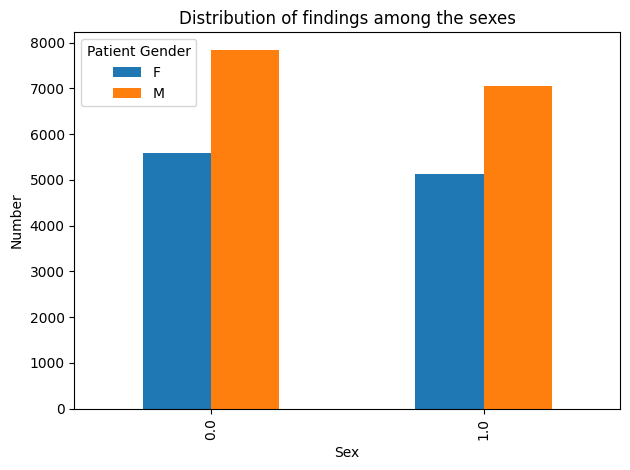

In [106]:
plt.figure()

drains_pivot_test.plot(kind="bar")
plt.title("Distribution of findings among the sexes")
plt.xlabel("Sex")
plt.ylabel("Number")
plt.tight_layout()
plt.show()

       OriginalImage[Width       Height]
count         86524.000000  86524.000000
mean           2641.784129   2505.106121
std             337.139196    403.957467
min            1143.000000    966.000000
25%            2500.000000   2048.000000
50%            2520.000000   2544.000000
75%            2992.000000   2991.000000
max            3550.000000   3166.000000


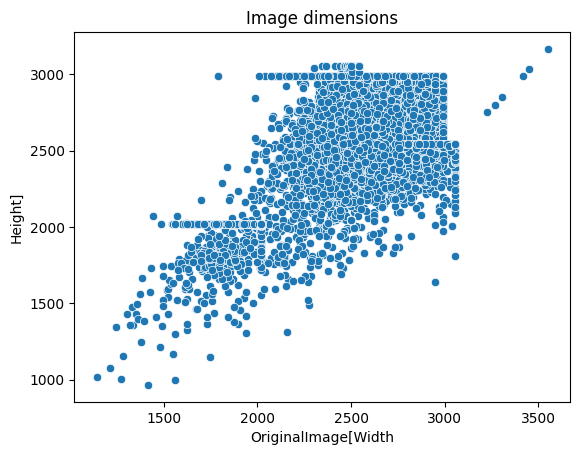

       OriginalImagePixelSpacing[x            y]
count                 86524.000000  86524.000000
mean                      0.155384      0.155384
std                       0.015615      0.015615
min                       0.115000      0.115000
25%                       0.143000      0.143000
50%                       0.143000      0.143000
75%                       0.168000      0.168000
max                       0.198800      0.198800
Asymmetric pixel spacing: 0


In [107]:
print(df_train[["OriginalImage[Width", "Height]"]].describe())
sns.scatterplot(data=df_train, x="OriginalImage[Width", y="Height]")
plt.title("Image dimensions")
plt.show()

print(df_train[["OriginalImagePixelSpacing[x", "y]"]].describe())
# finding mismatches between pixels
mismatch = df_train[df_train["OriginalImagePixelSpacing[x"] != df_train["y]"]]
print(f"Asymmetric pixel spacing: {len(mismatch)}")

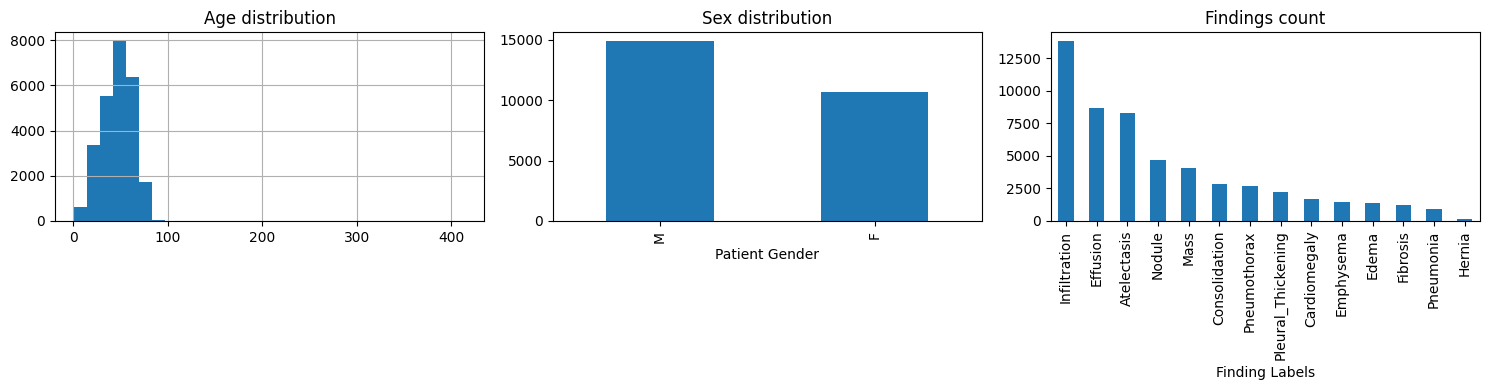

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_test["Patient Age"].hist(bins=30, ax=axes[0])
axes[0].set_title("Age distribution")

df_test["Patient Gender"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Sex distribution")

label_counts.drop("No Finding", errors="ignore").plot(kind="bar", ax=axes[2])
axes[2].set_title("Findings count")

plt.tight_layout()
plt.show()

In [109]:
df_test.sort_values(by="Patient Age")

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
6617,00010230_000.png,No Finding,0,10230,1,M,AP,2048,2500,115.000000,115.000000,NaN,NaN,NaN,NaN,0.0,False
12147,00015007_001.png,No Finding,1,15007,2,F,PA,1670,1769,143.000000,143.000000,NaN,NaN,NaN,NaN,0.0,False
24013,00029627_000.png,No Finding,0,29627,2,M,AP,2544,3056,139.000000,139.000000,NaN,NaN,NaN,NaN,0.0,False
6618,00010230_001.png,Infiltration,1,10230,2,M,AP,2048,2500,115.000000,115.000000,NaN,NaN,NaN,NaN,0.0,False
23324,00029093_000.png,No Finding,0,29093,3,M,AP,1189,1178,0.194311,0.194311,NaN,NaN,NaN,NaN,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23660,00029391_001.png,No Finding,1,29391,93,F,PA,2021,2021,0.194311,0.194311,NaN,NaN,NaN,NaN,0.0,False
15610,00018366_044.png,Pneumothorax,44,18366,152,F,PA,2302,2991,143.000000,143.000000,1.0,L,1.0,L,1.0,True
3488,00005567_000.png,Effusion|Pneumonia,0,5567,412,M,AP,3056,2544,139.000000,139.000000,NaN,NaN,NaN,NaN,1.0,False
17950,00021047_002.png,Mass|Pleural_Thickening,2,21047,412,M,AP,3056,2544,139.000000,139.000000,NaN,NaN,NaN,NaN,0.0,False


In [110]:
df_test["Patient ID"].value_counts()

Patient ID
10007    184
13670    173
15530    158
12834    157
13993    143
        ... 
29010      1
29008      1
29004      1
29003      1
30805      1
Name: count, Length: 2797, dtype: int64

In [111]:
df_test["Patient ID"].nunique()

2797

In [112]:
findings_pivot = (df_test.explode("Finding Labels").pivot_table(index="Finding Labels", columns="Patient Gender", 
                                   aggfunc="size", fill_value=0).sort_values(by=["F", "M"], ascending=False))
findings_pivot[:100]

Patient Gender,F,M
Finding Labels,,
No Finding,4151,5710
Infiltration,887,1333
Effusion,477,690
Pneumothorax,455,498
Atelectasis,338,463
...,...,...
Consolidation|Fibrosis,7,7
Atelectasis|Edema,7,5
Mass|Pleural_Thickening|Pneumothorax,7,2


<Figure size 640x480 with 0 Axes>

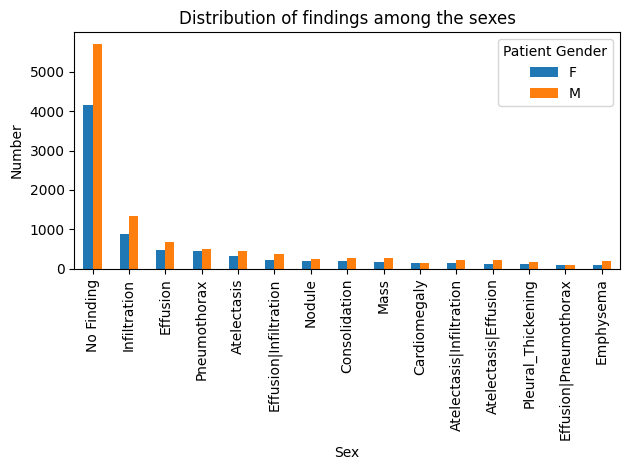

In [113]:
plt.figure()

findings_pivot[:15].plot(kind="bar")
plt.title("Distribution of findings among the sexes")
plt.xlabel("Sex")
plt.ylabel("Number")
plt.tight_layout()
plt.show()

# PadChest

In [114]:
df_padchest = pd.read_csv("../data/processed/padchest/processed_labels.csv")
df_padchest_px = pd.read_csv("../data/processed/padchest/processed_labels_px.csv")

In [115]:
df_padchest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108094 entries, 0 to 108093
Data columns (total 38 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   ImageID                          108094 non-null  object 
 1   ImageDir                         108094 non-null  int64  
 2   StudyDate_DICOM                  108094 non-null  object 
 3   StudyID                          108094 non-null  object 
 4   PatientID                        108094 non-null  object 
 5   PatientBirth                     108094 non-null  int64  
 6   PatientSex_DICOM                 108091 non-null  object 
 7   ViewPosition_DICOM               62879 non-null   object 
 8   Projection                       108094 non-null  object 
 9   MethodProjection                 108094 non-null  object 
 10  Pediatric                        108094 non-null  object 
 11  Modality_DICOM                   108094 non-null  object 
 12  Ma

In [116]:
df_padchest["Labels"]

0                                                ['normal']
1         ['pulmonary fibrosis', 'kyphosis', 'ground gla...
2                                       ['chronic changes']
3         ['interstitial pattern', 'alveolar pattern', '...
4         ['laminar atelectasis', 'sternotomy', 'pleural...
                                ...                        
108089        ['costophrenic angle blunting', 'copd signs']
108090                                           ['normal']
108091                    ['endotracheal tube', 'nsg tube']
108092                                           ['normal']
108093                                        ['pneumonia']
Name: Labels, Length: 108094, dtype: object

In [117]:
df_padchest["Manufacturer_DICOM"].value_counts()

Manufacturer_DICOM
ImagingDynamicsCompanyLtd    54348
PhilipsMedicalSystems        53746
Name: count, dtype: int64

In [ ]:
df_padchest_px["target_label"].value_counts()

target_label
0    107711
1       383
Name: count, dtype: int64

In [130]:
tester = (df_test.explode("Pneumothorax").pivot_table(index="Pneumothorax", 
                    columns=["Patient Gender"], aggfunc="size", fill_value=0))
tester["total"] = tester.sum(axis=1)
tester = tester.sort_values("total", ascending=False).drop(columns="total")
tester

Patient Gender,F,M
Pneumothorax,,
False,9483,13448
True,1231,1434


In [119]:
label_sex_crosstab_pt = (df_padchest_px.explode("target_label").pivot_table(index="target_label", 
                    columns=["PatientSex_DICOM", "Manufacturer_DICOM"], aggfunc="size", fill_value=0))
label_sex_crosstab_pt["total"] = label_sex_crosstab_pt.sum(axis=1)
label_sex_crosstab_pt = label_sex_crosstab_pt.sort_values("total", ascending=False).drop(columns="total")

In [120]:
label_sex_crosstab_pt

PatientSex_DICOM                           F                        \
Manufacturer_DICOM ImagingDynamicsCompanyLtd PhilipsMedicalSystems   
target_label                                                         
0                                      27997                 25510   
1                                         13                   124   

PatientSex_DICOM                           M                        \
Manufacturer_DICOM ImagingDynamicsCompanyLtd PhilipsMedicalSystems   
target_label                                                         
0                                      26305                 27882   
1                                         26                   220   

PatientSex_DICOM                           O                        
Manufacturer_DICOM ImagingDynamicsCompanyLtd PhilipsMedicalSystems  
target_label                                                        
0                                          6                     8  
1                                          0                     0

# PadChest scanners (pneumothorax)
**female patients** with pneumothorax: 13 (IDC) and 124 (PMS) = 137

**female patients** without pneumothorax: 27997	(IDC) and 25510 (PMS) = 53507

**male patients** with pneumothorax: 26 (IDC) and 220 (PMS) = 246

**male patients** without pneumothorax: 26305 (IDC) and 27882 (PMS) = 54187

In [121]:
label_sex_crosstab_pt

PatientSex_DICOM                           F                        \
Manufacturer_DICOM ImagingDynamicsCompanyLtd PhilipsMedicalSystems   
target_label                                                         
0                                      27997                 25510   
1                                         13                   124   

PatientSex_DICOM                           M                        \
Manufacturer_DICOM ImagingDynamicsCompanyLtd PhilipsMedicalSystems   
target_label                                                         
0                                      26305                 27882   
1                                         26                   220   

PatientSex_DICOM                           O                        
Manufacturer_DICOM ImagingDynamicsCompanyLtd PhilipsMedicalSystems  
target_label                                                        
0                                          6                     8  
1                                          0                     0

In [122]:
label_sex_crosstab = (df_padchest.explode("target_label").pivot_table(index="target_label", 
                    columns=["PatientSex_DICOM", "Manufacturer_DICOM"], aggfunc="size", fill_value=0))
label_sex_crosstab["total"] = label_sex_crosstab.sum(axis=1)
label_sex_crosstab = label_sex_crosstab.sort_values("total", ascending=False).drop(columns="total")

In [123]:
label_sex_crosstab

PatientSex_DICOM                           F                        \
Manufacturer_DICOM ImagingDynamicsCompanyLtd PhilipsMedicalSystems   
target_label                                                         
0                                      25234                 22967   
1                                       2776                  2667   

PatientSex_DICOM                           M                        \
Manufacturer_DICOM ImagingDynamicsCompanyLtd PhilipsMedicalSystems   
target_label                                                         
0                                      24391                 25825   
1                                       1940                  2277   

PatientSex_DICOM                           O                        
Manufacturer_DICOM ImagingDynamicsCompanyLtd PhilipsMedicalSystems  
target_label                                                        
0                                          5                     8  
1                                          1                     0

# PadChest scanners (cardiomegaly)
**ImagingDynamicsCompanyLtd** (IDC) overall: 25234 + 2776 + 24391 + 1940 = 54341

**PhilipsMedicalSystems** (PMS) overall: 22967 + 2667 + 25825 + 2277 = 53736

**ImagingDynamicsCompanyLtd** (IDC) for female patients: 25234 + 2776 = 28010

**PhilipsMedicalSystems** (PMS) for female patients: 22967 + 2667 = 25634

**ImagingDynamicsCompanyLtd** (IDC) for male patients: 24391 + 1940 = 26331

**PhilipsMedicalSystems** (PMS) for male patients: 25825 + 2277 = 28102

_________________________________
**female patients** with cardiomegaly: 2776 (IDC) and 2667 (PMS) = 5443

**female patients** without cardiomegaly: 25234	(IDC) and 22967 (PMS) = 48201

**male patients** with cardiomegaly: 1940 (IDC) and 2277 (PMS) = 4217

**male patients** without cardiomegaly: 24391 (IDC) and 25825 (PMS) = 50216